In [ ]:
import pandas as pd
import numpy as np
train = pd.read_csv('/content/application_train[1].csv')
test = pd.read_csv('/content/application_test[1].csv')
print(train.shape)
print(test.shape)

(38848, 122)
(48744, 121)


In [ ]:
train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
train.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [ ]:
train['TARGET'].head()

,TARGET
0,1
1,0
2,0
3,0
4,0


In [ ]:
train['TARGET'].value_counts()

,count
TARGET,
0,35719
1,3129


In [ ]:
train['TARGET'].value_counts(normalize=True)*100

,proportion
TARGET,
0,91.945531
1,8.054469


In [ ]:
train.shape

(38848, 122)

In [ ]:
train.dtypes.value_counts()

,count
float64,99
object,16
int64,7


float- numbers continous, int- binary, object-text

In [ ]:
train.select_dtypes(include = 'object').columns

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')

In [ ]:
train['CODE_GENDER'].value_counts()

,count
CODE_GENDER,
F,25538
M,13308
XNA,2


In [ ]:
train['CODE_GENDER'] = train['CODE_GENDER'].replace('XNA', np.nan)

In [ ]:
train['CODE_GENDER'].value_counts(dropna = False)

,count
CODE_GENDER,
F,25538
M,13308
NaN,2


nan = unknown value, dropna = unkown value hata do , dropna = true likhte toh count mai include nahi hota, false likha toh count mai agaya

In [ ]:
train['FLAG_OWN_CAR'].value_counts()

,count
FLAG_OWN_CAR,
N,25615
Y,13233


In [ ]:
train['FLAG_OWN_REALTY'].value_counts()

,count
FLAG_OWN_REALTY,
Y,27033
N,11815


In [ ]:
binary_cols = ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
for col in binary_cols:
  train[col] = train[col].map({'Y': 1, 'N':0})

In [ ]:
train[binary_cols].head()

,FLAG_OWN_CAR,FLAG_OWN_REALTY
0,0,1
1,0,0
2,1,1
3,0,1
4,0,1


isme basically data ko easily understand karne kai liye binary ka use karke y ko 1, n ko 0 dediya

In [ ]:
train['AMT_INCOME_TOTAL'].describe()

,AMT_INCOME_TOTAL
count,3.884800e+04
mean,1.711049e+05
std,6.008824e+05
min,2.565000e+04
25%,1.125000e+05
50%,1.440000e+05
75%,2.025000e+05
max,1.170000e+08


In [ ]:
train['AMT_INCOME_TOTAL_LOG'] = np.log1p(train['AMT_INCOME_TOTAL'])

In [ ]:
train[['AMT_INCOME_TOTAL','AMT_INCOME_TOTAL_LOG']].head()

,AMT_INCOME_TOTAL,AMT_INCOME_TOTAL_LOG
0,202500.0,12.218500
1,270000.0,12.506181
2,67500.0,11.119898
3,135000.0,11.813037
4,121500.0,11.707678


In [ ]:
train['DAYS_BIRTH'].describe()

,DAYS_BIRTH
count,38848.000000
mean,-16032.740476
std,4357.226298
min,-25182.000000
25%,-19666.000000
50%,-15754.500000
75%,-12390.000000
max,-7680.000000


age negative mai hai because yeh count hai days ka aur padt mai hai isliye negative, naya coulmn banayenge age ka better understnading aur data safe rakhne kai liye

In [ ]:
train['AGE_YEARS'] = -train['DAYS_BIRTH']/365

In [ ]:
train[['AGE_YEARS','DAYS_BIRTH']].head()

,AGE_YEARS,DAYS_BIRTH
0,25.920548,-9461
1,45.931507,-16765
2,52.180822,-19046
3,52.068493,-19005
4,54.608219,-19932


In [ ]:
train['AGE_YEARS'].isnull().sum()

np.int64(0)

missing nahi varna median use karte kyunki age skewed variable hai so median is robust to outlinears

In [ ]:
missing = train.isnull().mean().sort_values(ascending = False)
missing.head(10)

,0
COMMONAREA_AVG,0.701297
COMMONAREA_MODE,0.701297
COMMONAREA_MEDI,0.701297
NONLIVINGAPARTMENTS_AVG,0.695480
NONLIVINGAPARTMENTS_MODE,0.695480
NONLIVINGAPARTMENTS_MEDI,0.695480
LIVINGAPARTMENTS_MEDI,0.685878
LIVINGAPARTMENTS_MODE,0.685878
LIVINGAPARTMENTS_AVG,0.685878
FONDKAPREMONT_MODE,0.685492


now we know ki more than 70 percent data hai hi nahi toh use drop kar denge

In [ ]:
high_missing = missing[missing > 0.6]
high_missing

,0
COMMONAREA_AVG,0.701297
COMMONAREA_MODE,0.701297
COMMONAREA_MEDI,0.701297
NONLIVINGAPARTMENTS_AVG,0.695480
NONLIVINGAPARTMENTS_MODE,0.695480
NONLIVINGAPARTMENTS_MEDI,0.695480
LIVINGAPARTMENTS_MEDI,0.685878
LIVINGAPARTMENTS_MODE,0.685878
LIVINGAPARTMENTS_AVG,0.685878
FONDKAPREMONT_MODE,0.685492


In [ ]:
train = train.drop(columns = high_missing.index)

In [ ]:
train.shape

(38848, 107)

In [ ]:
train.isnull().mean().sort_values(ascending = False).head(10)

,0
LANDAREA_MEDI,0.595629
LANDAREA_MODE,0.595629
LANDAREA_AVG,0.595629
BASEMENTAREA_MODE,0.584818
BASEMENTAREA_MEDI,0.584818
BASEMENTAREA_AVG,0.584818
EXT_SOURCE_1,0.564456
NONLIVINGAREA_MEDI,0.551637
NONLIVINGAREA_AVG,0.551637
NONLIVINGAREA_MODE,0.551637


In [ ]:
train['EXIT_SOURCE_1'] = train['EXT_SOURCE_1'].fillna(train['EXT_SOURCE_1'].median())

In [ ]:
train['EXIT_SOURCE_1'].isnull().mean()

np.float64(0.0)

basically humne exit score joh ki credit card score jaisa hota hai usme median daal kr fill kardiya kyunki yeh code mai agge kaam ayega

In [ ]:
drop_cols = ['LANDAREA_MEDI','LANDAREA_MODE','LANDAREA_AVG','BASEMENTAREA_MODE','BASEMENTAREA_MEDI','BASEMENTAREA_AVG','NONLIVINGAREA_MEDI','NONLIVINGAREA_AVG','NONLIVINGAREA_MODE']

In [ ]:
train = train.drop(columns = drop_cols)

In [ ]:
train.isnull().mean().sort_values(ascending = False).head(10)

,0
EXT_SOURCE_1,0.564456
ELEVATORS_AVG,0.533387
ELEVATORS_MEDI,0.533387
ELEVATORS_MODE,0.533387
WALLSMATERIAL_MODE,0.509910
APARTMENTS_MEDI,0.507928
APARTMENTS_AVG,0.507928
APARTMENTS_MODE,0.507928
ENTRANCES_MODE,0.504247
ENTRANCES_MEDI,0.504247


hum wall material kai alava sab drop kar denge voh kaam hai, duplicated nahi hai , imp ho saakte hai, voh mode yani test hai toh uski jagah mode use karke text bharenge

In [ ]:
drop_cols2 = ['ELEVATORS_MEDI','ELEVATORS_MODE','ELEVATORS_AVG','APARTMENTS_MODE','APARTMENTS_AVG','APARTMENTS_MEDI','ENTRANCES_AVG','ENTRANCES_MODE','ENTRANCES_MEDI']

In [ ]:
train = train.drop(columns = drop_cols2)

In [ ]:
train['WALLSMATERIAL_MODE'] = train['WALLSMATERIAL_MODE'].fillna(train['WALLSMATERIAL_MODE'].mode()[0])

In [ ]:
train.isnull().mean().sort_values(ascending = False).head(10)

,0
EXT_SOURCE_1,0.564456
LIVINGAREA_MEDI,0.503938
LIVINGAREA_AVG,0.503938
LIVINGAREA_MODE,0.503938
HOUSETYPE_MODE,0.502214
FLOORSMAX_AVG,0.497786
FLOORSMAX_MODE,0.497786
FLOORSMAX_MEDI,0.497786
YEARS_BEGINEXPLUATATION_AVG,0.488777
YEARS_BEGINEXPLUATATION_MODE,0.488777


In [ ]:
drop_cols3 = [
    'LIVINGAREA_MEDI', 'LIVINGAREA_MODE', 'LIVINGAREA_AVG',
    'FLOORSMAX_AVG', 'FLOORSMAX_MODE', 'FLOORSMAX_MEDI',
    'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BEGINEXPLUATATION_MEDI'
]


In [ ]:
train = train.drop(columns=drop_cols3)


In [ ]:
train['HOUSETYPE_MODE'] = train['HOUSETYPE_MODE'].fillna(
    train['HOUSETYPE_MODE'].mode()[0]
)

In [ ]:
train.isnull().mean().sort_values(ascending=False).head(10)

,0
EXT_SOURCE_1,0.564456
TOTALAREA_MODE,0.483526
EMERGENCYSTATE_MODE,0.474490
OCCUPATION_TYPE,0.314585
EXT_SOURCE_3,0.197900
AMT_REQ_CREDIT_BUREAU_YEAR,0.134602
AMT_REQ_CREDIT_BUREAU_WEEK,0.134602
AMT_REQ_CREDIT_BUREAU_DAY,0.134602
AMT_REQ_CREDIT_BUREAU_QRT,0.134602
AMT_REQ_CREDIT_BUREAU_MON,0.134602


In [ ]:
numeric_fill = [
    'TOTALAREA_MODE',
    'EXT_SOURCE_3',
    'AMT_REQ_CREDIT_BUREAU_QRT',
    'AMT_REQ_CREDIT_BUREAU_YEAR',
    'AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_HOUR',
    'AMT_REQ_CREDIT_BUREAU_MON'
]

In [ ]:
for col in numeric_fill:
    train[col] = train[col].fillna(train[col].median())

In [ ]:
categorical_fill = [
    'EMERGENCYSTATE_MODE',
    'OCCUPATION_TYPE'
]


In [ ]:
for col in categorical_fill:
    train[col] = train[col].fillna(train[col].mode()[0])

In [ ]:
train.isnull().mean().sort_values(ascending=False).head(10)

,0
EXT_SOURCE_1,0.564456
NAME_TYPE_SUITE,0.003938
OBS_60_CNT_SOCIAL_CIRCLE,0.003346
OBS_30_CNT_SOCIAL_CIRCLE,0.003346
DEF_30_CNT_SOCIAL_CIRCLE,0.003346
DEF_60_CNT_SOCIAL_CIRCLE,0.003346
EXT_SOURCE_2,0.002471
AMT_GOODS_PRICE,0.000746
CODE_GENDER,0.000051
DAYS_LAST_PHONE_CHANGE,0.000051


In [ ]:
numeric_small = [
    'OBS_60_CNT_SOCIAL_CIRCLE',
    'DEF_60_CNT_SOCIAL_CIRCLE',
    'DEF_30_CNT_SOCIAL_CIRCLE',
    'OBS_30_CNT_SOCIAL_CIRCLE',
    'EXT_SOURCE_2',
    'AMT_GOODS_PRICE',
    'AMT_ANNUITY',
    'CNT_FAM_MEMBERS'
]

for col in numeric_small:
    train[col] = train[col].fillna(train[col].median())

In [ ]:
categorical_small = [
    'NAME_TYPE_SUITE',
    'CODE_GENDER'
]

for col in categorical_small:
    train[col] = train[col].fillna(train[col].mode()[0])

In [ ]:
train.isnull().mean().sort_values(ascending=False).head(10)

,0
EXT_SOURCE_1,0.564456
DAYS_LAST_PHONE_CHANGE,0.000051
REG_REGION_NOT_LIVE_REGION,0.000026
WEEKDAY_APPR_PROCESS_START,0.000026
REG_REGION_NOT_WORK_REGION,0.000026
REG_CITY_NOT_LIVE_CITY,0.000026
REG_CITY_NOT_WORK_CITY,0.000026
LIVE_REGION_NOT_WORK_REGION,0.000026
HOUR_APPR_PROCESS_START,0.000026
FLAG_CONT_MOBILE,0.000026


In [ ]:
X = train.drop('TARGET', axis=1)
Y = train['TARGET']

In [ ]:
X.shape


(38848, 80)

In [ ]:
Y.shape

(38848,)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.2, random_state = 42, stratify = Y)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)


In [ ]:
X_train.dtypes.value_counts()


,count
float64,59
object,13
int64,8


In [ ]:
X_train.select_dtypes(include = 'object').columns

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_TYPE_SUITE',
       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START',
       'ORGANIZATION_TYPE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE',
       'EMERGENCYSTATE_MODE'],
      dtype='object')

In [ ]:
X_train = pd.get_dummies(X_train, drop_first = True)
X_test = pd.get_dummies(X_test, drop_first = True)

In [ ]:
X_train.shape

(31078, 183)

In [ ]:
X_test.shape

(7770, 177)

In [ ]:
X_train,X_test = X_train.align(X_test, join = 'left', axis = 1, fill_value = 0)

In [ ]:
X_train.shape

(31078, 183)

In [ ]:
X_test.shape

(7770, 183)

In [ ]:
from sklearn.linear_model import LogisticRegression

# Impute any remaining NaN values in X_train and X_test
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

model = LogisticRegression(max_iter = 1000)
model.fit(X_train,Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
X_train.isnull().sum().sum()

np.int64(0)

In [ ]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [ ]:
X_train.isnull().sum().sum()

np.int64(0)

In [ ]:
model.fit(X_train, Y_train)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
model = LogisticRegression(max_iter=200, solver='liblinear')
model.fit(X_train, Y_train)

LogisticRegression(max_iter=200, solver='liblinear')

In [ ]:
model.coef_

array([[-7.64512868e-06, -1.73536467e-07, -5.77596102e-08,
        -1.40209808e-08,  2.99821211e-08,  3.16494135e-06,
         9.45218071e-06, -4.13412750e-06, -6.71836266e-09,
         6.49663746e-05,  4.96044181e-07,  2.41541857e-05,
         5.87710962e-05, -4.76798927e-08, -4.45982990e-08,
         8.61221152e-08, -4.17154494e-08, -1.44341700e-07,
        -3.52603968e-08, -1.95146754e-07,  3.26221349e-07,
         3.27909396e-07, -1.92413422e-06,  1.04840873e-08,
        -1.89477422e-08, -2.61560318e-08,  2.68146429e-08,
         1.09952642e-07,  1.02097100e-07, -1.32488679e-07,
        -3.76318053e-07, -3.54920417e-07, -3.20367142e-08,
         3.43026849e-07,  2.23513807e-07,  3.29088544e-07,
         1.86673049e-07,  2.22481697e-04,  1.56974628e-09,
         2.16147867e-07, -4.59079557e-10, -2.79086323e-09,
        -5.16108944e-09, -6.10363084e-10, -7.57848341e-08,
        -5.60846935e-09,  0.00000000e+00, -8.19312525e-09,
         0.00000000e+00, -1.25287863e-08, -1.22034479e-0

In [ ]:
len(model.coef_[0])

183

In [ ]:
Y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,Y_pred)

0.9194337194337194

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(Y_test,Y_pred)

array([[7144,    0],
       [ 626,    0]])

In [ ]:
model = LogisticRegression(max_iter=200, solver='liblinear', class_weight='balanced')
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
accuracy_score(Y_test, Y_pred)


0.5823680823680824

In [ ]:
confusion_matrix(Y_test, Y_pred)

array([[4135, 3009],
       [ 236,  390]])

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.95      0.58      0.72      7144
           1       0.11      0.62      0.19       626

    accuracy                           0.58      7770
   macro avg       0.53      0.60      0.46      7770
weighted avg       0.88      0.58      0.68      7770



In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)

In [ ]:
Y_train_smote.value_counts()

,count
TARGET,
0,28575
1,28575


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_smote, Y_train_smote)

RandomForestClassifier(random_state=42)

In [ ]:
Y_pred_new = rf_model.predict(X_test)


In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(Y_test, Y_pred_new))

[[7125   19]
 [ 622    4]]


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, Y_pred_new))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96      7144
           1       0.17      0.01      0.01       626

    accuracy                           0.92      7770
   macro avg       0.55      0.50      0.48      7770
weighted avg       0.86      0.92      0.88      7770



In [ ]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending = False)
print(feature_importances.head(10))

EXT_SOURCE_3                                         0.058091
EXT_SOURCE_2                                         0.037404
FLAG_PHONE                                           0.034260
NAME_EDUCATION_TYPE_Secondary / secondary special    0.031757
CODE_GENDER_M                                        0.031726
OBS_30_CNT_SOCIAL_CIRCLE                             0.031507
AMT_REQ_CREDIT_BUREAU_YEAR                           0.030835
FLAG_DOCUMENT_3                                      0.030824
OBS_60_CNT_SOCIAL_CIRCLE                             0.030122
REGION_RATING_CLIENT_W_CITY                          0.029679
dtype: float64


In [ ]:
from sklearn.metrics import accuracy_score
rf_accuracy = accuracy_score(Y_test, Y_pred_new)
print("Random Forest Accuracy:", rf_accuracy)


Random Forest Accuracy: 0.9175032175032175


In [ ]:
log_accuracy = accuracy_score(Y_test, Y_pred)
print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.5823680823680824


In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [log_accuracy, rf_accuracy]
})
print(results)



                 Model  Accuracy
0  Logistic Regression  0.582368
1        Random Forest  0.917503


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, Y_pred_new)
print(cm)

[[7125   19]
 [ 622    4]]


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, Y_pred_new))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96      7144
           1       0.17      0.01      0.01       626

    accuracy                           0.92      7770
   macro avg       0.55      0.50      0.48      7770
weighted avg       0.86      0.92      0.88      7770



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_

feature_importance = pd.Series(importances, index=X_train.columns)

feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

EXT_SOURCE_3                                         0.058091
EXT_SOURCE_2                                         0.037404
FLAG_PHONE                                           0.034260
NAME_EDUCATION_TYPE_Secondary / secondary special    0.031757
CODE_GENDER_M                                        0.031726
OBS_30_CNT_SOCIAL_CIRCLE                             0.031507
AMT_REQ_CREDIT_BUREAU_YEAR                           0.030835
FLAG_DOCUMENT_3                                      0.030824
OBS_60_CNT_SOCIAL_CIRCLE                             0.030122
REGION_RATING_CLIENT_W_CITY                          0.029679
dtype: float64


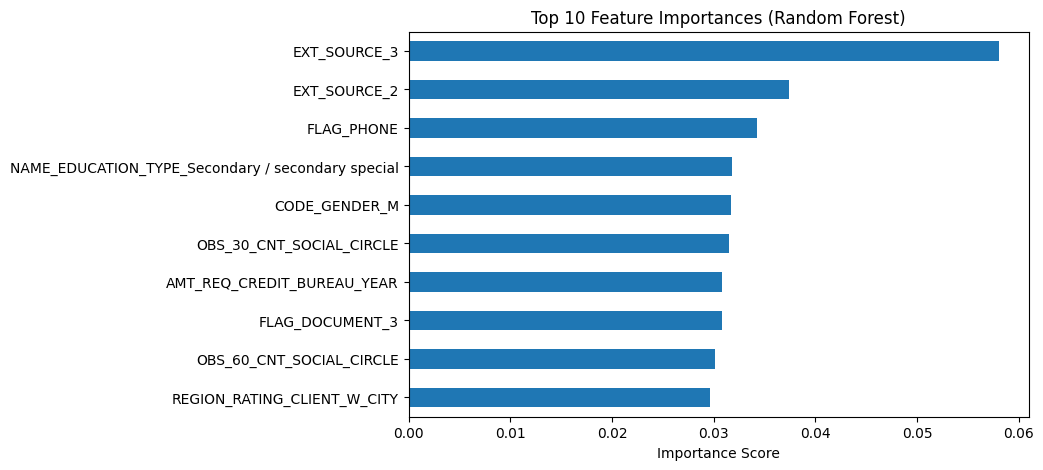

In [ ]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))
top_features.plot(kind='barh')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd

# Preprocess X for cross-validation
# Apply one-hot encoding to X
X_processed = pd.get_dummies(X, drop_first=True)

# Fill any remaining NaN values in X_processed, consistent with X_train and X_test
X_processed = X_processed.fillna(0)

# Random Forest cross-validation
scores = cross_val_score(rf_model, X_processed, Y, cv=5, scoring='accuracy')

print("Cross-Validation Scores:", scores)
print("Average CV Score:", np.mean(scores))

Cross-Validation Scores: [0.91943372 0.91943372 0.91943372 0.91942335 0.91723517]
Average CV Score: 0.9189919345821005
